In [1]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.preprocessing import image_dataset_from_directory

In [2]:
from sklearn.datasets import make_circles
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from keras.models import Sequential
from keras.layers import Dense

In [3]:
IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 100

In [4]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
"Disease",
shuffle = True,
image_size = (IMAGE_SIZE,IMAGE_SIZE),
batch_size = BATCH_SIZE
)

Found 684 files belonging to 3 classes.


In [5]:
class_names = dataset.class_names
class_names

['Measles', 'Monkeypox', 'Normal']

(32, 256, 256, 3)
[2 1 2 2 1 1 1 2 2 2 2 2 2 2 0 2 1 2 1 2 2 2 2 2 1 2 1 1 1 1 1 0]


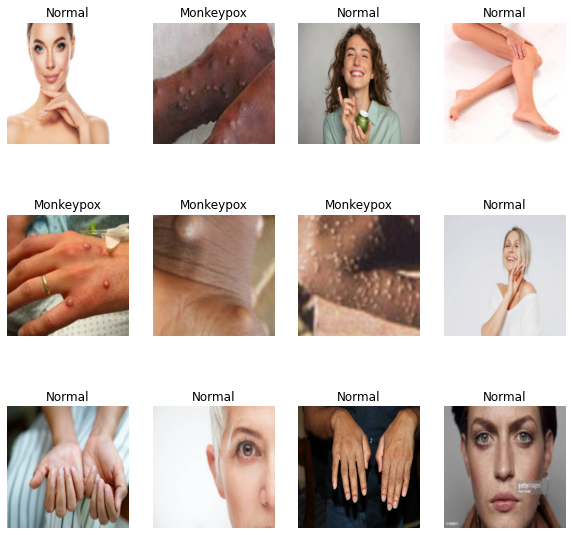

In [6]:
plt.figure(figsize=(10,10))
for image_batch, labels_batch in dataset.take(1):
    print(image_batch.shape)
    print(labels_batch.numpy())
    for i in range(12):
        ax = plt.subplot(3,4,i+1)
        plt.title(class_names[labels_batch[i]])
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.axis("off")

In [7]:
train_size = 0.8
len(dataset)*train_size

17.6

In [8]:
train_ds = dataset.take(16)
len(train_ds)

16

In [9]:
test_ds = dataset.skip(16)
len(test_ds)

6

In [10]:
val_size = 0.1
len(dataset)*val_size

2.2

In [11]:
#80% ==> Training
#20% ==> Test
    #10% ==> Validation
    #10% ==> Test

In [12]:
val_ds = test_ds.take(2)
len(val_ds)

2

In [13]:
test_ds = test_ds.skip(2)
len(test_ds)

4

In [14]:
def get_dataset_partition_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    assert(train_split+test_split+val_split)==1
    
    ds_size= len(ds)
    
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
    
    train_size = int(train_split*ds_size)
    val_size = int(val_split*ds_size)
    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    
    return train_ds, val_ds, test_ds

In [15]:
train_ds, val_ds, test_ds = get_dataset_partition_tf(dataset)

In [16]:
len(train_ds)

17

In [17]:
len(val_ds)

2

In [18]:
len(test_ds)

3

In [19]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [20]:
for image_batch, labels_batch in dataset.take(1):
    print(image_batch[0].numpy()/255)

[[[0.03137255 0.03137255 0.03137255]
  [0.025      0.025      0.025     ]
  [0.02892157 0.02892157 0.02892157]
  ...
  [0.02083333 0.02083333 0.02083333]
  [0.02647059 0.02647059 0.02647059]
  [0.03921569 0.03921569 0.03921569]]

 [[0.02181373 0.02181373 0.02181373]
  [0.01803003 0.01803003 0.01803003]
  [0.02254902 0.02254902 0.02254902]
  ...
  [0.01665135 0.01665135 0.01665135]
  [0.01890319 0.01890319 0.01890319]
  [0.02647059 0.02647059 0.02647059]]

 [[0.02230392 0.02230392 0.02230392]
  [0.02130821 0.02130821 0.02130821]
  [0.01905637 0.01905637 0.01905637]
  ...
  [0.01568628 0.01568628 0.01568628]
  [0.01816789 0.01816789 0.01816789]
  [0.02892157 0.02892157 0.02892157]]

 ...

 [[0.13504902 0.09583333 0.06053922]
  [0.12688419 0.09722733 0.05874694]
  [0.12196691 0.09451593 0.05530025]
  ...
  [0.16755515 0.12833945 0.09304535]
  [0.16902573 0.1304994  0.09497549]
  [0.1622549  0.12671569 0.09019608]]

 [[0.1245098  0.08455882 0.05294118]
  [0.13566177 0.10586704 0.07046568]


In [21]:
resize_and_rescale = tf.keras.Sequential([
    layers.experimental.preprocessing.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.experimental.preprocessing.Rescaling(1.0/255)
])

In [22]:
data_augmentation = tf.keras.Sequential([
    layers.experimental.preprocessing.RandomFlip("horizontal_and_vertical"),
    layers.experimental.preprocessing.RandomRotation(0.2)
])

In [23]:
input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE,CHANNELS)
n_classes = 3

model = models.Sequential([
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(32,kernel_size=(3,3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
    
    
    
])

model.build(input_shape = input_shape)

In [24]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (32, 256, 256, 3)         0         
                                                                 
 sequential_1 (Sequential)   (None, 256, 256, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 254, 254, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 127, 127, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 125, 125, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 62, 62, 64)       0         
 2D)                                                  

In [25]:
X = train_ds
y= test_ds

In [26]:
model.compile(
   optimizer='adam', 
   loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits= False),
   metrics=['accuracy']
)

In [27]:
history = model.fit(
    train_ds,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    verbose=1,
    epochs=EPOCHS
)

Epoch 1/100
17/17 [==============================] - 81s 3s/step - loss: 0.9998 - accuracy: 0.4427 - val_loss: 0.9546 - val_accuracy: 0.5312
Epoch 2/100
17/17 [==============================] - 55s 3s/step - loss: 0.9701 - accuracy: 0.4866 - val_loss: 0.9509 - val_accuracy: 0.5312
Epoch 3/100
17/17 [==============================] - 55s 3s/step - loss: 0.9498 - accuracy: 0.4733 - val_loss: 0.8979 - val_accuracy: 0.5312
Epoch 4/100
17/17 [==============================] - 48s 3s/step - loss: 0.9062 - accuracy: 0.5477 - val_loss: 0.8513 - val_accuracy: 0.5469
Epoch 5/100
17/17 [==============================] - 45s 3s/step - loss: 0.9075 - accuracy: 0.5878 - val_loss: 0.8753 - val_accuracy: 0.5625
Epoch 6/100
17/17 [==============================] - 43s 3s/step - loss: 0.9135 - accuracy: 0.5267 - val_loss: 0.9463 - val_accuracy: 0.4688
Epoch 7/100
17/17 [==============================] - 44s 3s/step - loss: 0.9155 - accuracy: 0.5592 - val_loss: 0.8480 - val_accuracy: 0.6094
Epoch 8/100
1

Epoch 49/100
17/17 [==============================] - 25s 1s/step - loss: 0.2420 - accuracy: 0.9084 - val_loss: 0.5564 - val_accuracy: 0.8594
Epoch 50/100
17/17 [==============================] - 27s 2s/step - loss: 0.2685 - accuracy: 0.8989 - val_loss: 0.5372 - val_accuracy: 0.8438
Epoch 51/100
17/17 [==============================] - 24s 1s/step - loss: 0.2657 - accuracy: 0.9160 - val_loss: 0.6082 - val_accuracy: 0.8750
Epoch 52/100
17/17 [==============================] - 28s 2s/step - loss: 0.3023 - accuracy: 0.8931 - val_loss: 0.4152 - val_accuracy: 0.8438
Epoch 53/100
17/17 [==============================] - 31s 2s/step - loss: 0.3738 - accuracy: 0.8588 - val_loss: 0.4600 - val_accuracy: 0.8750
Epoch 54/100
17/17 [==============================] - 33s 2s/step - loss: 0.2594 - accuracy: 0.8969 - val_loss: 0.3533 - val_accuracy: 0.9375
Epoch 55/100
17/17 [==============================] - 32s 2s/step - loss: 0.2263 - accuracy: 0.9122 - val_loss: 0.5304 - val_accuracy: 0.8750
Epoch 

In [28]:
scores = model.evaluate(test_ds)

3/3 [==============================] - 4s 394ms/step - loss: 0.3865 - accuracy: 0.9375


In [29]:
history.history['accuracy']

[0.442748099565506,
 0.4866412281990051,
 0.47328245639801025,
 0.5477099418640137,
 0.5877862572669983,
 0.5267175436019897,
 0.5591602921485901,
 0.6297709941864014,
 0.6393129825592041,
 0.669847309589386,
 0.6717557311058044,
 0.6832060813903809,
 0.6965649127960205,
 0.7156488299369812,
 0.6984732747077942,
 0.7290076613426208,
 0.7232824563980103,
 0.7480915784835815,
 0.7194656729698181,
 0.7595419883728027,
 0.7595419883728027,
 0.7729007601737976,
 0.7786259651184082,
 0.7881679534912109,
 0.7862595319747925,
 0.7996183037757874,
 0.8129770755767822,
 0.8320610523223877,
 0.8206107020378113,
 0.8015267252922058,
 0.8320610523223877,
 0.822519063949585,
 0.847328245639801,
 0.8416030406951904,
 0.8492366671562195,
 0.8702290058135986,
 0.8702290058135986,
 0.8816794157028198,
 0.8568702340126038,
 0.8530534505844116,
 0.8893129825592041,
 0.8740457892417908,
 0.902671754360199,
 0.8912213444709778,
 0.9064885377883911,
 0.8969465494155884,
 0.902671754360199,
 0.906488537788391

In [30]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

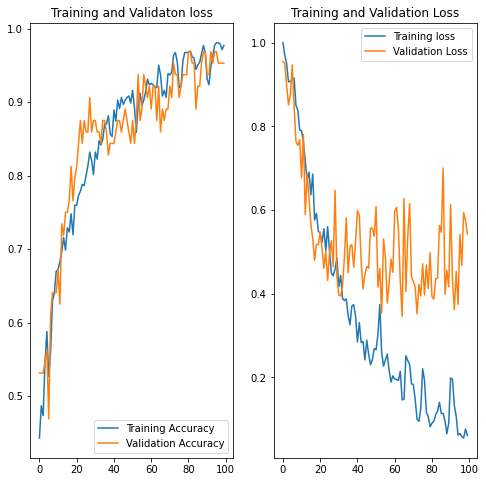

In [31]:
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validaton loss')

plt.subplot(1,2,2)
plt.plot(range(EPOCHS), loss,label='Training loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()


First image to predict
Label: Measles
1/1 [==============================] - 1s 1s/step
Predicted Label: Measles


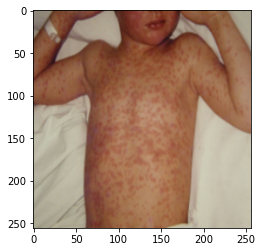

In [32]:
import numpy as np
for images_batch, labels_batch in test_ds.take(1):
    
    first_image = images_batch[0].numpy().astype("uint8")
    
    print("First image to predict")
    plt.imshow(first_image)
    print("Label:", class_names[labels_batch[0].numpy()])
    
    batch_prediction = model.predict(images_batch)
    print("Predicted Label:",class_names[np.argmax(batch_prediction[0])])

In [ ]:
model_version = 1
model.save(f"../Models/{model_version}")

In [ ]:
!git status

In [35]:
!git init
!git add .
!git commit -m "Second commit"

Reinitialized existing Git repository in C:/Users/DELL/Desktop/skin/.git/


[main 3cd93cb] Second commit
 5 files changed, 390 insertions(+), 619 deletions(-)
 create mode 100644 Models/1/keras_metadata.pb
 create mode 100644 Models/1/saved_model.pb
 create mode 100644 Models/1/variables/variables.data-00000-of-00001
 create mode 100644 Models/1/variables/variables.index


In [36]:
!git branch -M main
#!git remote add origin https://github.com/Sakhawat-Saim/disease-ditection.git
!git push -u origin main

error: remote origin already exists.


branch 'main' set up to track 'origin/main'.


To https://github.com/Sakhawat-Saim/disease-ditection.git
   7bc812e..3cd93cb  main -> main
